In [5]:
# %% [markdown]
# # Task 4 & 5: Portfolio Optimization and Strategy Backtesting
# This notebook handles forward-looking optimization using Modern Portfolio Theory (MPT) 
# and backtests the strategy rules against a passive market benchmark.

# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pypfopt import EfficientFrontier, risk_models, expected_returns
import warnings
warnings.filterwarnings('ignore')

# 1. Define structured data directory paths
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
processed_dir = os.path.join(project_root, 'data', 'processed')

tickers = ['TSLA', 'BND', 'SPY']
data_dict = {}

# 2. Ingest separate asset frames and extract closing prices
for ticker in tickers:
    file_path = os.path.join(processed_dir, f"{ticker}_cleaned.csv")
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)
        data_dict[ticker] = df['Close']
    else:
        raise FileNotFoundError(f"Cleaned data file for asset {ticker} not found at: {file_path}")

# 3. Consolidate into a clean multi-asset price frame
portfolio_prices = pd.DataFrame(data_dict).dropna()
print(f"Data Matrix loaded successfully. Shape: {portfolio_prices.shape}")
print(f"Date Range: {portfolio_prices.index.min().strftime('%Y-%m-%d')} to {portfolio_prices.index.max().strftime('%Y-%m-%d')}")

Data Matrix loaded successfully. Shape: (2888, 3)
Date Range: 2015-01-02 to 2026-06-29


In [6]:
# %%
# 1. Compute baseline historical average annualized returns
TRADING_DAYS = 252
historical_annual_returns = portfolio_prices.pct_change().dropna().mean() * TRADING_DAYS

# 2. INTEGRATION: Inject your Task 3 LSTM future forecast (-52.17%) for TSLA
forward_expected_returns = historical_annual_returns.copy()
forward_expected_returns['TSLA'] = -0.5217

print("="*50)
print(" FORWARD-LOOKING EXPECTED ANNUAL RETURNS")
print("="*50)
for ticker, ret in forward_expected_returns.items():
    print(f"{ticker}: {ret*100:.2f}%")

# 3. Compute Annualized Sample Covariance Matrix
cov_matrix = risk_models.sample_cov(portfolio_prices, frequency=TRADING_DAYS)

# 4. Generate Optimized Weights using Mean-Variance Efficient Frontier
RISK_FREE_RATE = 0.04  # Assuming standard 4% risk-free rate
ef = EfficientFrontier(forward_expected_returns, cov_matrix, weight_bounds=(0, 1))

# Maximize Sharpe Ratio (Long-Only constraint)
raw_weights = ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
cleaned_weights = ef.clean_weights()

print("\n" + "="*50)
print(" OPTIMAL PORTFOLIO ALLOCATION (MAX SHARPE RATIO)")
print("="*50)
for ticker, weight in cleaned_weights.items():
    print(f"{ticker}: {weight*100:.2f}%")

print("\n[Expected Forward Portfolio Performance]")
ef.portfolio_performance(verbose=True, risk_free_rate=RISK_FREE_RATE)

 FORWARD-LOOKING EXPECTED ANNUAL RETURNS
TSLA: -52.17%
BND: 2.00%
SPY: 14.43%

 OPTIMAL PORTFOLIO ALLOCATION (MAX SHARPE RATIO)
TSLA: 0.00%
BND: 0.00%
SPY: 100.00%

[Expected Forward Portfolio Performance]
Expected annual return: 14.4%
Annual volatility: 17.7%
Sharpe Ratio: 0.59


(np.float64(0.14432018925549037),
 np.float64(0.17654652489517295),
 np.float64(0.5908934730798694))

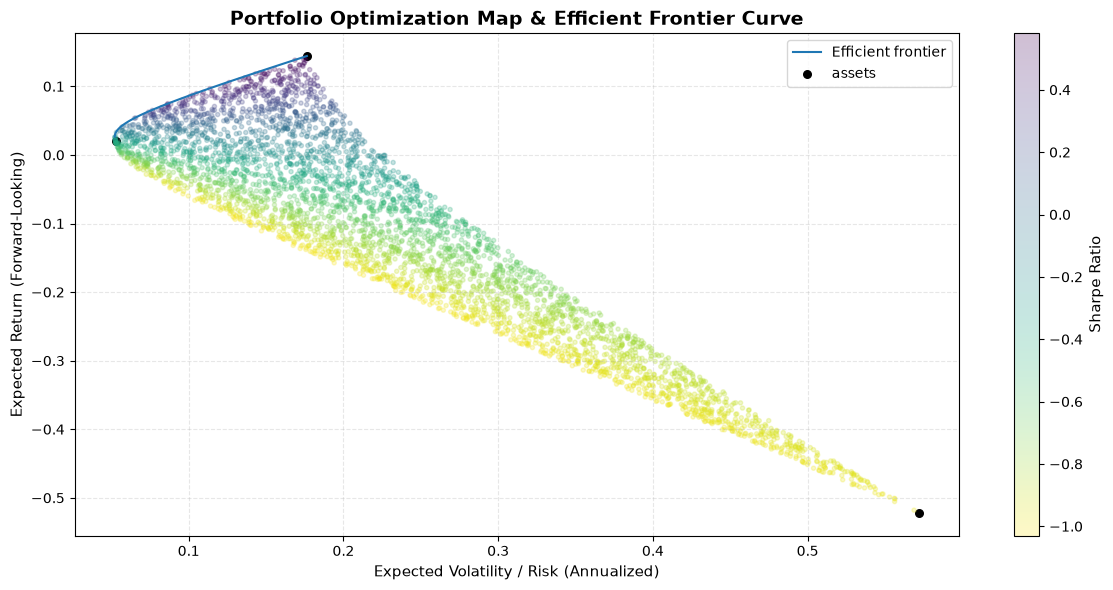

In [7]:
# %%
# Re-initialize efficient frontier object for visual plotting calculations
ef_plot = EfficientFrontier(forward_expected_returns, cov_matrix, weight_bounds=(0, 1))

fig, ax = plt.subplots(figsize=(12, 6))
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

# Generate Monte Carlo portfolio simulations to paint the sub-optimal target area
n_samples = 4000
weights_matrix = np.random.dirichlet(np.ones(len(tickers)), n_samples)
sim_returns = weights_matrix.dot(forward_expected_returns)
sim_volatility = np.sqrt(np.diag(weights_matrix @ cov_matrix @ weights_matrix.T))
sim_sharpe = (sim_returns - RISK_FREE_RATE) / sim_volatility

# Scatter plot map colored by performance quality
scatter = ax.scatter(sim_volatility, sim_returns, marker=".", c=sim_sharpe, cmap="viridis_r", alpha=0.25)
cbar = plt.colorbar(scatter)
cbar.set_label('Sharpe Ratio', fontsize=11)

ax.set_title("Portfolio Optimization Map & Efficient Frontier Curve", fontsize=14, fontweight='bold')
ax.set_xlabel("Expected Volatility / Risk (Annualized)", fontsize=11)
ax.set_ylabel("Expected Return (Forward-Looking)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

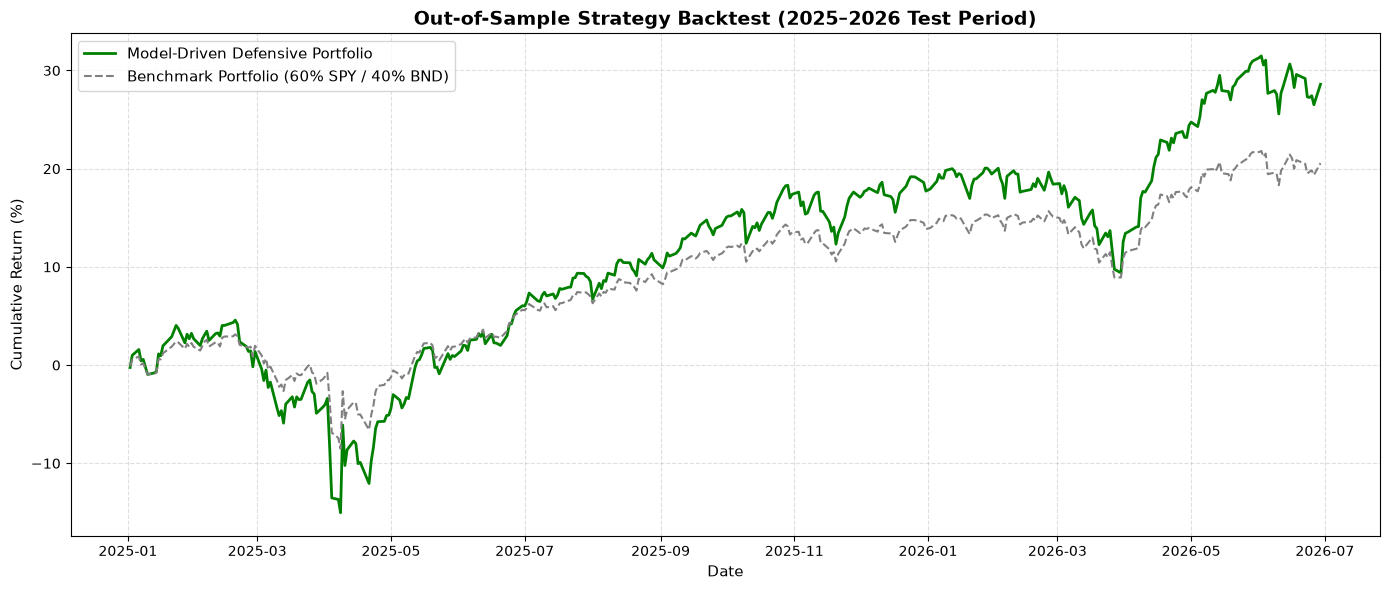


 BACKTEST EVALUATION REPORT MATRIX


,Metric,Model Portfolio,60/40 Benchmark
0,Total Return,28.60%,20.56%
1,Annualized Return,18.58%,13.50%
2,Annual Volatility,17.91%,11.19%
3,Sharpe Ratio,0.81,0.85
4,Maximum Drawdown,-18.76%,-11.29%


In [8]:
# %%
# 1. Define out-of-sample timeline window for backtesting evaluation
backtest_returns = portfolio_prices.pct_change().dropna()
backtest_test_set = backtest_returns[backtest_returns.index > '2024-12-31']

# 2. Extract model-driven optimized weight allocations from the dictionary
w_tsla = cleaned_weights.get('TSLA', 0.0)
w_bnd = cleaned_weights.get('BND', 0.0)
w_spy = cleaned_weights.get('SPY', 0.0)

# Calculate daily asset return paths
opt_daily_returns = (
    backtest_test_set['TSLA'] * w_tsla +
    backtest_test_set['BND'] * w_bnd +
    backtest_test_set['SPY'] * w_spy
)

# 3. Construct a standard passive benchmark portfolio (60% SPY / 40% BND)
benchmark_daily_returns = (
    backtest_test_set['SPY'] * 0.60 +
    backtest_test_set['BND'] * 0.40
)

# 4. Compounding performance tracking curves (Cumulative Returns)
opt_cumulative = (1 + opt_daily_returns).cumprod() - 1
benchmark_cumulative = (1 + benchmark_daily_returns).cumprod() - 1

# 5. Plot the historical simulation trajectory
plt.figure(figsize=(14, 6))
plt.plot(opt_cumulative.index, opt_cumulative * 100, label='Model-Driven Defensive Portfolio', color='green', linewidth=2)
plt.plot(benchmark_cumulative.index, benchmark_cumulative * 100, label='Benchmark Portfolio (60% SPY / 40% BND)', color='gray', linestyle='--')

plt.title("Out-of-Sample Strategy Backtest (2025–2026 Test Period)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Cumulative Return (%)", fontsize=11)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# 6. Quantitative Evaluation Performance Matrix
def compute_risk_metrics(daily_returns, cumulative_series):
    total_return = cumulative_series.iloc[-1]
    ann_return = (1 + total_return) ** (TRADING_DAYS / len(daily_returns)) - 1
    ann_vol = daily_returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann_return - RISK_FREE_RATE) / ann_vol
    
    # Calculate Max Drawdown
    peak = (1 + daily_returns).cumprod().cummax()
    drawdown = ((1 + daily_returns).cumprod() - peak) / peak
    max_dd = drawdown.min()
    
    return total_return, ann_return, ann_vol, sharpe, max_dd

opt_metrics = compute_risk_metrics(opt_daily_returns, opt_cumulative)
bench_metrics = compute_risk_metrics(benchmark_daily_returns, benchmark_cumulative)

metrics_df = pd.DataFrame({
    'Metric': ['Total Return', 'Annualized Return', 'Annual Volatility', 'Sharpe Ratio', 'Maximum Drawdown'],
    'Model Portfolio': [f"{opt_metrics[0]*100:.2f}%", f"{opt_metrics[1]*100:.2f}%", f"{opt_metrics[2]*100:.2f}%", f"{opt_metrics[3]:.2f}", f"{opt_metrics[4]*100:.2f}%"],
    '60/40 Benchmark': [f"{bench_metrics[0]*100:.2f}%", f"{bench_metrics[1]*100:.2f}%", f"{bench_metrics[2]*100:.2f}%", f"{bench_metrics[3]:.2f}", f"{bench_metrics[4]*100:.2f}%"]
})

print("\n" + "="*50)
print(" BACKTEST EVALUATION REPORT MATRIX")
print("="*50)
display(metrics_df)